ФЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ ОБРАЗОВАТЕЛЬНОЕ
БЮДЖЕТНОЕ УЧРЕЖДЕНИЕ ВЫСШЕГО ОБРАЗОВАНИЯ
«ФИНАНСОВЫЙ УНИВЕРСИТЕТ ПРИ ПРАВИТЕЛЬСТВЕ
РОССИЙСКОЙ ФЕДЕРАЦИИ»
(ФИНАНСОВЫЙ УНИВЕРСИТЕТ). Кафедра искусственного интеллекта
Факультета информационных технологий и анализа больших данных. Дисциплина: «Машинное обучение в семантическом и сетевом анализе». Направление подготовки: «Прикладная математика и информатика». Профиль: «Прикладное машинное обучение». Форма обучения очная. Учебный 2025/2026 год, 6 семестр.


Выполнил: студент группы ПМ23-6 Аникин Д.А.

Научный руководитель: Казанцев А.М.

In [ ]:
import time
import tracemalloc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Импорт библиотек
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, MDS, trustworthiness
from sklearn.random_projection import GaussianRandomProjection
from sklearn.metrics import pairwise_distances
from scipy.stats import pearsonr

import umap
import pacmap
import trimap

import optuna

Основные характеристики

In [2]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data.astype(np.float32)
y = mnist.target.astype(int)

np.random.seed(42)
idx = np.random.choice(len(X), size=3000, replace=False)
X_sample, y_sample = X[idx], y[idx]

print(f"Размер выборки: {X_sample.shape[0]} объектов")
print(f"Размерность признаков: {X_sample.shape[1]} (28×28 пикселей)")
print(f"Диапазон значений: [{X_sample.min():.2f}, {X_sample.max():.2f}]")
print(f"Тип данных: {X_sample.dtype}")

Размер выборки: 3000 объектов
Размерность признаков: 784 (28×28 пикселей)
Диапазон значений: [0.00, 255.00]
Тип данных: float32


Проверка на пропуски

In [3]:
missing_values = np.isnan(X_sample).sum()
missing_per_feature = np.isnan(X_sample).sum(axis=0)

print(f"Пропущенные значения (всего): {missing_values}")
print(f"Признаки с пропусками: {(missing_per_feature > 0).sum()}")

Пропущенные значения (всего): 0
Признаки с пропусками: 0


Статистики по признакам (пикселям)

In [4]:
feature_stats = pd.DataFrame({
    'mean': X_sample.mean(axis=0),
    'std': X_sample.std(axis=0),
    'min': X_sample.min(axis=0),
    'max': X_sample.max(axis=0),
    'median': np.median(X_sample, axis=0)
})

print(feature_stats.describe())

# Доля нулевых пикселей (фон)
zero_ratio = (X_sample == 0).sum() / X_sample.size
print(f"\nДоля нулевых значений (фон): {zero_ratio:.2%}")

             mean         std    min         max      median
count  784.000000  784.000000  784.0  784.000000  784.000000
mean    33.452454   49.137218    0.0  196.346939   12.476403
std     42.678932   44.315659    0.0  102.690010   33.326550
min      0.000000    0.000000    0.0    0.000000    0.000000
25%      0.113333    4.386576    0.0  194.250000    0.000000
50%      7.422833   37.246471    0.0  255.000000    0.000000
75%     68.696167  100.677059    0.0  255.000000    0.000000
max    139.514664  114.773857    0.0  255.000000  173.500000

Доля нулевых значений (фон): 80.81%


Распределение классов

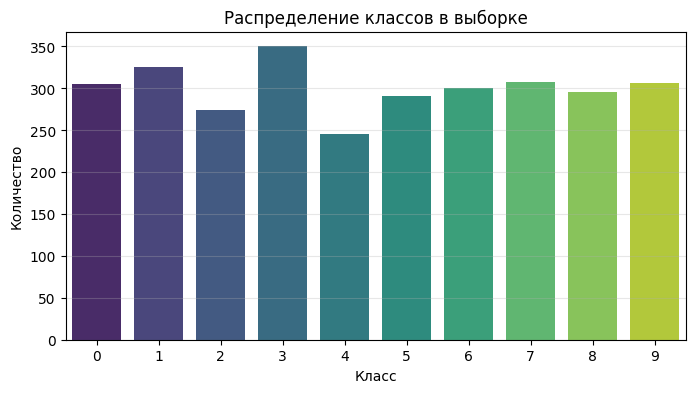

0    305
1    325
2    274
3    350
4    246
5    291
6    300
7    308
8    295
9    306
Name: count, dtype: int64


In [5]:
class_counts = pd.Series(y_sample).value_counts().sort_index()

plt.figure(figsize=(8, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.title('Распределение классов в выборке')
plt.grid(axis='y', alpha=0.3)
plt.show()

print(class_counts)

Дисперсия признаков

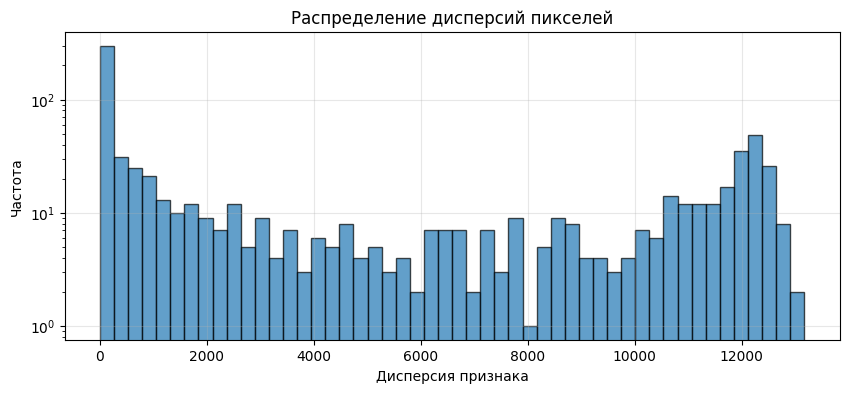

Признаки с низкой дисперсией (<1% от макс): 272/784 (34.7%)


In [6]:
variances = X_sample.var(axis=0)

plt.figure(figsize=(10, 4))
plt.hist(variances, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Дисперсия признака')
plt.ylabel('Частота')
plt.title('Распределение дисперсий пикселей')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.show()

# Признаки с низкой дисперсией (< 1% от макс)
low_var_thresh = variances.max() * 0.01
low_var_count = (variances < low_var_thresh).sum()
print(f"Признаки с низкой дисперсией (<1% от макс): {low_var_count}/{len(variances)} ({low_var_count/len(variances):.1%})")

Выборка 50 случайных признаков для визуализации корреляций

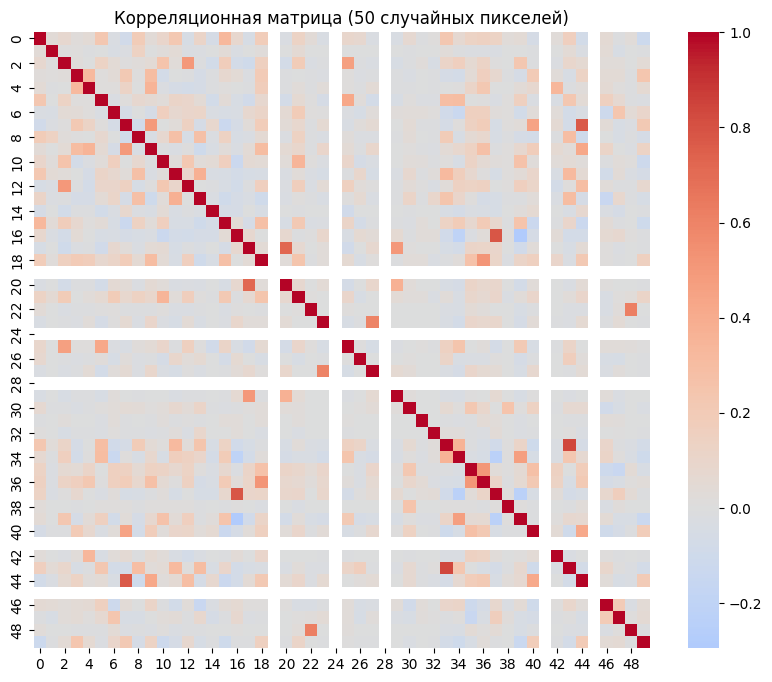

Средняя абсолютная корреляция (выборка): nan


In [7]:
np.random.seed(42)
sample_feats = np.random.choice(784, size=50, replace=False)
X_corr = X_sample[:, sample_feats]

plt.figure(figsize=(10, 8))
sns.heatmap(np.corrcoef(X_corr.T), cmap='coolwarm', center=0, square=True)
plt.title('Корреляционная матрица (50 случайных пикселей)')
plt.show()

# Средняя абсолютная корреляция
mean_abs_corr = np.abs(np.corrcoef(X_corr.T)).mean()
print(f"Средняя абсолютная корреляция (выборка): {mean_abs_corr:.3f}")

Визуализация 10 случайных изображений из выборки

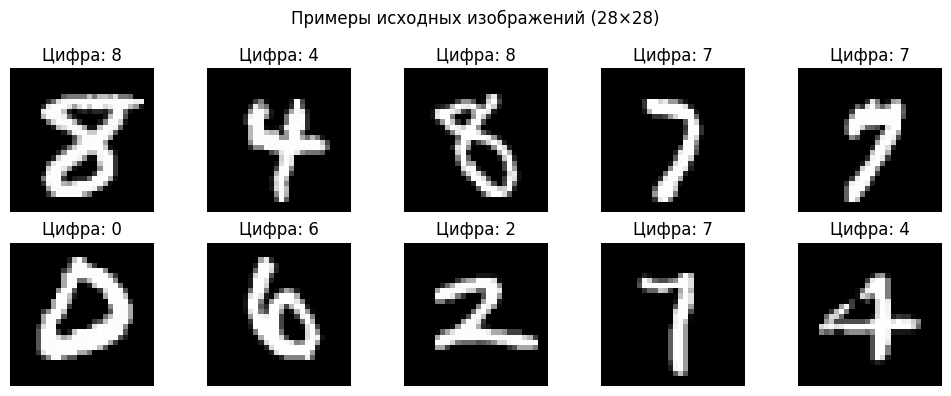

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img = X_sample[i].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Цифра: {y_sample[i]}')
    ax.axis('off')
plt.suptitle('Примеры исходных изображений (28×28)')
plt.tight_layout()
plt.show()

Функция загрузка подвыборки MNIST как прокси для сложных эмбеддингов.

In [9]:
def load_embeddings(n_samples=3000, random_state=42):
    print("📥 Загрузка данных (MNIST 784D)...")
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    X, y = mnist.data, mnist.target.astype(int)
    
    np.random.seed(random_state)
    idx = np.random.choice(len(X), min(n_samples, len(X)), replace=False)
    X, y = X[idx], y[idx]
    
    X = StandardScaler().fit_transform(X)
    print(f"✅ Датасет готов: {X.shape[0]} объектов, {X.shape[1]} признаков")
    return X, y


Функция расчёта Trustworthiness (локальная структура) и корреляции расстояний (глобальная структура).

In [10]:
def compute_quality_metrics(X_high, X_low, n_ref=1000):
    trust = trustworthiness(X_high, X_low, n_neighbors=10)
    n = min(n_ref, len(X_high))
    idx = np.random.choice(len(X_high), n, replace=False)
    d_high = pairwise_distances(X_high[idx], metric='euclidean')
    d_low = pairwise_distances(X_low[idx], metric='euclidean')
    triu = np.triu_indices(n, k=1)
    corr, _ = pearsonr(d_high[triu], d_low[triu])
    return trust, 1 - abs(corr)

Функция для модулирования предложенных методов. Автоматический подсчет метрик.

In [11]:
def run_dr_method(name, func, X, y, **kwargs):
    print(f"\🔄 {name}...")
    tracemalloc.start()
    t0 = time.perf_counter()
    try:
        X_low = func(X, **kwargs)
    except Exception as e:
        print(f"❌ Ошибка: {e}")
        return None
    t1 = time.perf_counter()
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    elapsed = t1 - t0
    peak_mb = peak / 10**6
    trust, corr = compute_quality_metrics(X, X_low)
    print(f" ⏱ {elapsed:.1f}с| 💾 {peak_mb:.0f}МБ| 🎯 Trust: {trust:.3f}| 🌍 Corr: {corr:.3f}")
    return {"Метод": name, "Время (с)": elapsed, "Память (МБ)": peak_mb, "Trustworthiness": trust, "Global_Corr": corr, "X_low": X_low}


Функция для сравнения методов. Применяет ранее созданную функцию run_dr_method, где параметр func - используемый метод. Также применяю optuna для подбора параметров. Для метода MDS подбор не произвожу, так как это крайне долго по времени. Можно было подобрать параметры на меньшей выборке, но я не стал этого делать.

In [12]:
def run_comparison(X, y, n_trials=20):
    methods_list = ["Random Projection", "PCA", "t-SNE", "UMAP", "TriMap", "PaCMAP", "MDS"]
    results = []
    for name in methods_list:
        def objective(trial):
            if name == "Random Projection":
                kwargs = {"n_components": 2, "eps": trial.suggest_float("eps", 0.1, 0.5)}
                X_low = GaussianRandomProjection(**kwargs, random_state=42).fit_transform(X)
            elif name == "PCA":
                kwargs = {"n_components": 2, "random_state": 42}
                X_low = PCA(**kwargs).fit_transform(X)
            elif name == "t-SNE":
                kwargs = {"n_components": 2, "perplexity": trial.suggest_float("perplexity", 5.0, 50.0), "learning_rate": trial.suggest_float("learning_rate", 10.0, 1000.0, log=True), "random_state": 42, "n_jobs": -1}
                X_low = TSNE(**kwargs).fit_transform(X)
            elif name == "UMAP":
                kwargs = {"n_components": 2, "n_neighbors": trial.suggest_int("n_neighbors", 5, 50), "min_dist": trial.suggest_float("min_dist", 0.0, 1.0), "random_state": 42, "n_jobs": -1}
                X_low = umap.UMAP(**kwargs).fit_transform(X)
            elif name == "TriMap":
                kwargs = {"n_dims": 2, "n_inliers": trial.suggest_int("n_inliers", 5, 50), "n_outliers": trial.suggest_int("n_outliers", 1, 20), "n_random": trial.suggest_int("n_random", 1, 30)}
                X_low = trimap.TRIMAP(**kwargs).fit_transform(X)
            elif name == "PaCMAP":
                kwargs = {"n_components": 2, "n_neighbors": trial.suggest_int("n_neighbors", 5, 50), "random_state": 42}
                X_low = pacmap.PaCMAP(**kwargs).fit_transform(X)
            elif name == "MDS":
                X_low = MDS(n_components=2, metric=True, random_state=42, n_jobs=1).fit_transform(X)
            trust, corr = compute_quality_metrics(X, X_low)
            return trust + corr

        if name != "MDS":
            study = optuna.create_study(direction="maximize")
            study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
            best_params = study.best_params
            if name != 'TriMap':
                best_params["n_components"] = 2
                best_params["random_state"] = 42
            if name == "t-SNE": best_params["n_jobs"] = -1
            if name == "UMAP": best_params["n_jobs"] = -1
            if name == "Random Projection": func = lambda x: GaussianRandomProjection(**best_params).fit_transform(x)
            elif name == "PCA": func = lambda x: PCA(**best_params).fit_transform(x)
            elif name == "t-SNE": func = lambda x: TSNE(**best_params).fit_transform(x)
            elif name == "UMAP": func = lambda x: umap.UMAP(**best_params).fit_transform(x)
            elif name == "TriMap": func = lambda x: trimap.TRIMAP(**best_params).fit_transform(x)
            elif name == "PaCMAP": func = lambda x: pacmap.PaCMAP(**best_params).fit_transform(x)
        else:
            func = lambda x: MDS(n_components=2, metric=True, random_state=42, n_jobs=1).fit_transform(x)

        res = run_dr_method(name + (" (Opt)" if name != "MDS" else ""), func, X, y)
        if res is not None:
            results.append(res)

    final_df = pd.DataFrame(results)[["Метод", "Время (с)", "Память (МБ)", "Trustworthiness", "Global_Corr"]]
    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    axes = axes.flatten()
    legend_handles, legend_labels = None, None
    for i, res in enumerate(results):
        if i < len(axes):
            ax = axes[i]
            sns.scatterplot(x=res["X_low"][:,0], y=res["X_low"][:,1], hue=y, palette="tab10", legend=False, ax=ax, s=15, alpha=0.75)
            if legend_handles is None:
                legend_handles, legend_labels = ax.get_legend_handles_labels()
            ax.set_title(f"{res['Метод']}\n⏱ {res['Время (с)']:.1f}с | 💾 {res['Память (МБ)']:.0f}МБ\n🎯 {res['Trustworthiness']:.2f} | 🌍 {res['Global_Corr']:.2f}", fontsize=10, pad=10)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.grid(True, alpha=0.3)
    legend_ax = axes[len(results)]
    legend_ax.axis('off')
    legend_ax.legend(
        handles=legend_handles,
        labels=legend_labels,
        loc='center',
        title="Цифры MNIST",
        frameon=True,
        fontsize=11,
        title_fontsize=13,
        framealpha=0.95,
        edgecolor='gray',
        ncol=2
    )
    plt.suptitle("Сравнительная визуализация методов снижения размерности (MNIST 784D)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    print("\📊 ИТОГОВАЯ ТАБЛИЦА ДЛЯ ПОЯСНИТЕЛЬНОЙ ЗАПИСКИ:")
    display(final_df.style.set_table_styles([{'selector': 'th', 'props': [('background-color', '#f5f5f5'), ('font-weight', 'bold')]}, {'selector': 'td', 'props': [('text-align', 'center')]}]))
    final_df.to_csv("dr_comparison_results.csv", index=False)
    print("\💾 Результаты сохранены в dr_comparison_results.csv")
    return final_df

Запуск функции run_comparison

📥 Загрузка данных (MNIST 784D)...


[I 2026-05-26 12:45:17,383] A new study created in memory with name: no-name-f26d7383-1c30-465a-b637-cd77f56fc99b


✅ Датасет готов: 3000 объектов, 784 признаков


[I 2026-05-26 12:45:18,867] Trial 0 finished with value: 1.1129575965827292 and parameters: {'eps': 0.3967378630149839}. Best is trial 0 with value: 1.1129575965827292.
[I 2026-05-26 12:45:20,051] Trial 1 finished with value: 1.021220493686299 and parameters: {'eps': 0.4502934965363591}. Best is trial 0 with value: 1.1129575965827292.
[I 2026-05-26 12:45:21,023] Trial 2 finished with value: 1.1089233957037776 and parameters: {'eps': 0.11889028853549002}. Best is trial 0 with value: 1.1129575965827292.
[I 2026-05-26 12:45:22,100] Trial 3 finished with value: 1.0279150032024813 and parameters: {'eps': 0.2350176577288198}. Best is trial 0 with value: 1.1129575965827292.
[I 2026-05-26 12:45:23,025] Trial 4 finished with value: 1.0478415589759482 and parameters: {'eps': 0.3008128285647478}. Best is trial 0 with value: 1.1129575965827292.
[I 2026-05-26 12:45:24,013] Trial 5 finished with value: 1.0608488498712725 and parameters: {'eps': 0.42363037179363394}. Best is trial 0 with value: 1.112

\🔄 Random Projection (Opt)...


...

\🔄 TriMap (Opt)...


[I 2026-05-26 12:57:47,833] A new study created in memory with name: no-name-b09e181d-d815-44ff-8292-0ee43edb9b09


 ⏱ 52.0с| 💾 42МБ| 🎯 Trust: 0.890| 🌍 Corr: 0.984


[I 2026-05-26 12:58:01,670] Trial 0 finished with value: 1.8647751806923196 and parameters: {'n_neighbors': 50}. Best is trial 0 with value: 1.8647751806923196.
[I 2026-05-26 12:58:06,860] Trial 1 finished with value: 1.8694973802983363 and parameters: {'n_neighbors': 12}. Best is trial 1 with value: 1.8694973802983363.
[I 2026-05-26 12:58:15,807] Trial 2 finished with value: 1.8713975375806085 and parameters: {'n_neighbors': 27}. Best is trial 2 with value: 1.8713975375806085.
[I 2026-05-26 12:58:23,790] Trial 3 finished with value: 1.8571839380560857 and parameters: {'n_neighbors': 22}. Best is trial 2 with value: 1.8713975375806085.
[I 2026-05-26 12:58:29,735] Trial 4 finished with value: 1.8526729097207815 and parameters: {'n_neighbors': 14}. Best is trial 2 with value: 1.8713975375806085.
[I 2026-05-26 12:58:38,753] Trial 5 finished with value: 1.863991543891728 and parameters: {'n_neighbors': 28}. Best is trial 2 with value: 1.8713975375806085.
[I 2026-05-26 12:58:50,281] Trial 6

\🔄 PaCMAP (Opt)...
 ⏱ 7.9с| 💾 28МБ| 🎯 Trust: 0.878| 🌍 Corr: 0.992
\🔄 MDS...
 ⏱ 552.8с| 💾 540МБ| 🎯 Trust: 0.681| 🌍 Corr: 0.170


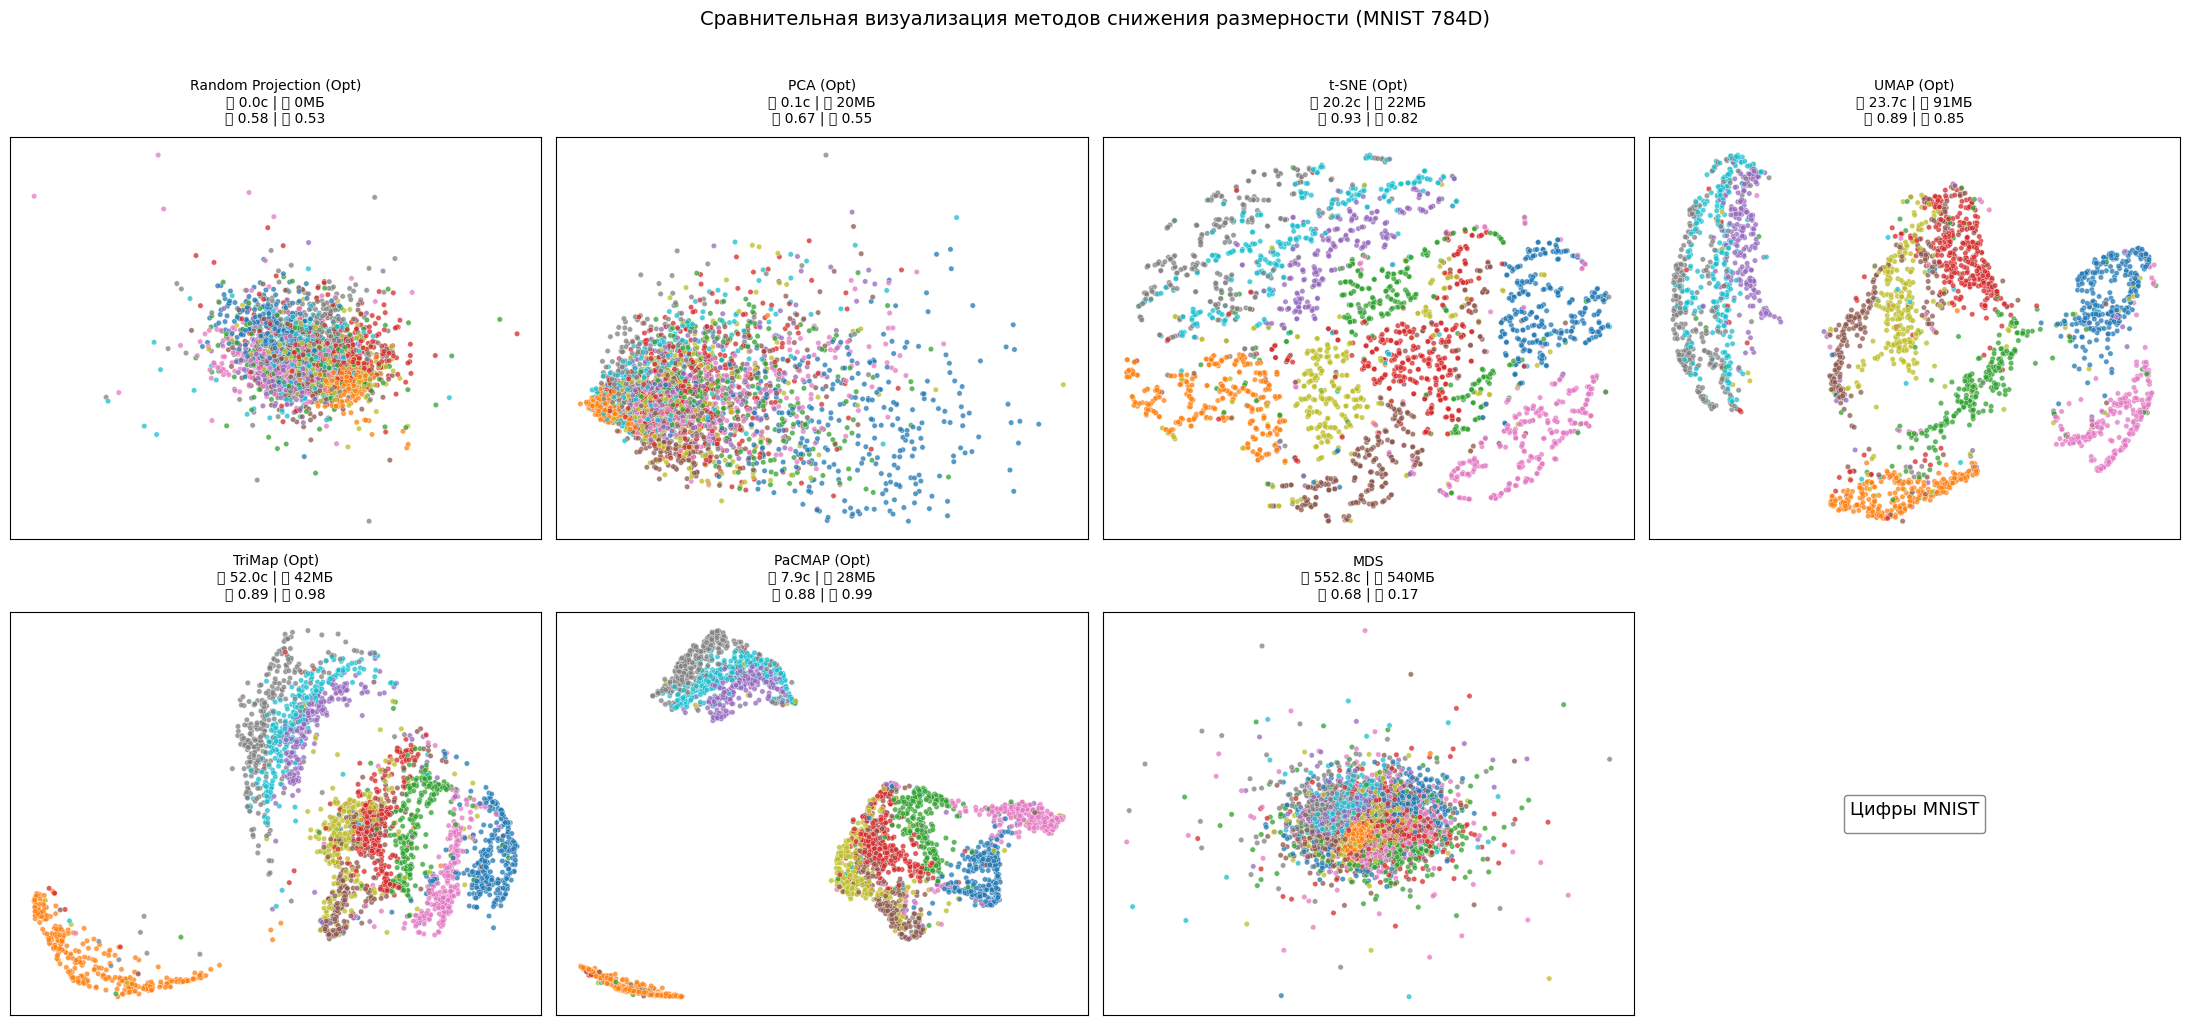

\📊 ИТОГОВАЯ ТАБЛИЦА ДЛЯ ПОЯСНИТЕЛЬНОЙ ЗАПИСКИ:


,Метод,Время (с),Память (МБ),Trustworthiness,Global_Corr
0,Random Projection (Opt),0.009505,0.062930,0.580070,0.534282
1,PCA (Opt),0.062381,19.794054,0.669461,0.550480
2,t-SNE (Opt),20.169729,21.982362,0.931508,0.818803
3,UMAP (Opt),23.651666,91.196720,0.893046,0.846865
4,TriMap (Opt),52.043881,41.572946,0.889956,0.984075
5,PaCMAP (Opt),7.912333,28.226416,0.878052,0.992278
6,MDS,552.827966,540.178767,0.680533,0.169737


\💾 Результаты сохранены в dr_comparison_results.csv

📊 ИТОГОВАЯ ТАБЛИЦА ДЛЯ ПОЯСНИТЕЛЬНОЙ ЗАПИСКИ:


,Метод,Время (с),Память (МБ),Trustworthiness,Global_Corr
0,Random Projection (Opt),0.009505,0.062930,0.580070,0.534282
1,PCA (Opt),0.062381,19.794054,0.669461,0.550480
2,t-SNE (Opt),20.169729,21.982362,0.931508,0.818803
3,UMAP (Opt),23.651666,91.196720,0.893046,0.846865
4,TriMap (Opt),52.043881,41.572946,0.889956,0.984075
5,PaCMAP (Opt),7.912333,28.226416,0.878052,0.992278
6,MDS,552.827966,540.178767,0.680533,0.169737



💾 Результаты сохранены в dr_comparison_results.csv


In [13]:
if __name__ == "__main__":
    X, y = load_embeddings(n_samples=3000) 
    comparison_df = run_comparison(X, y)
    
    print("\n📊 ИТОГОВАЯ ТАБЛИЦА ДЛЯ ПОЯСНИТЕЛЬНОЙ ЗАПИСКИ:")
    display(comparison_df.style.set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f5f5f5'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('text-align', 'center')]}
    ]))
    
    # Экспорт для отчёта
    comparison_df.to_csv("dr_comparison_results.csv", index=False)
    print("\n💾 Результаты сохранены в dr_comparison_results.csv")